In [1]:
import pandas as pd
import miceforest as mf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("Institutional_data_full.csv")

In [3]:
data_for_imputation = data.drop(['Country', 'Year'], axis=1)

data_for_imputation = data_for_imputation.apply(pd.to_numeric, errors='coerce')

kernel = mf.ImputationKernel(
    data_for_imputation,
    num_datasets = 1,
    mean_match_candidates=0,
    random_state = 28
    )


kernel.mice(30)
imputed_data = kernel.complete_data(0)

imputed_data['Country'] = data['Country']
imputed_data['Year'] = data['Year']

imputed_data.to_csv("Testing.csv", index=False)

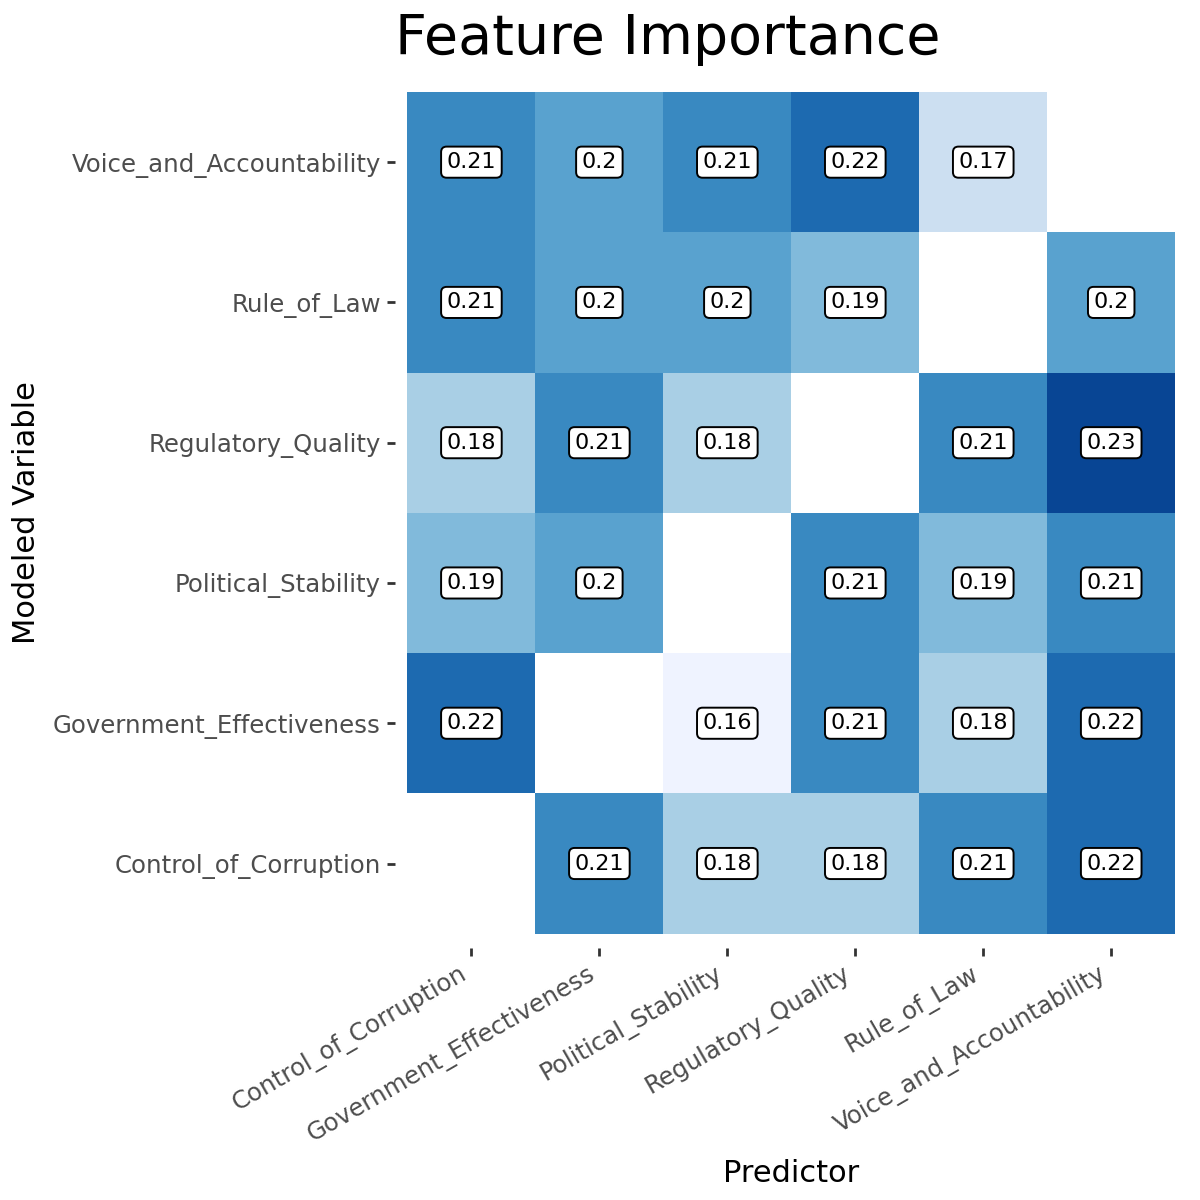

In [4]:
kernel.plot_feature_importance(dataset=0)

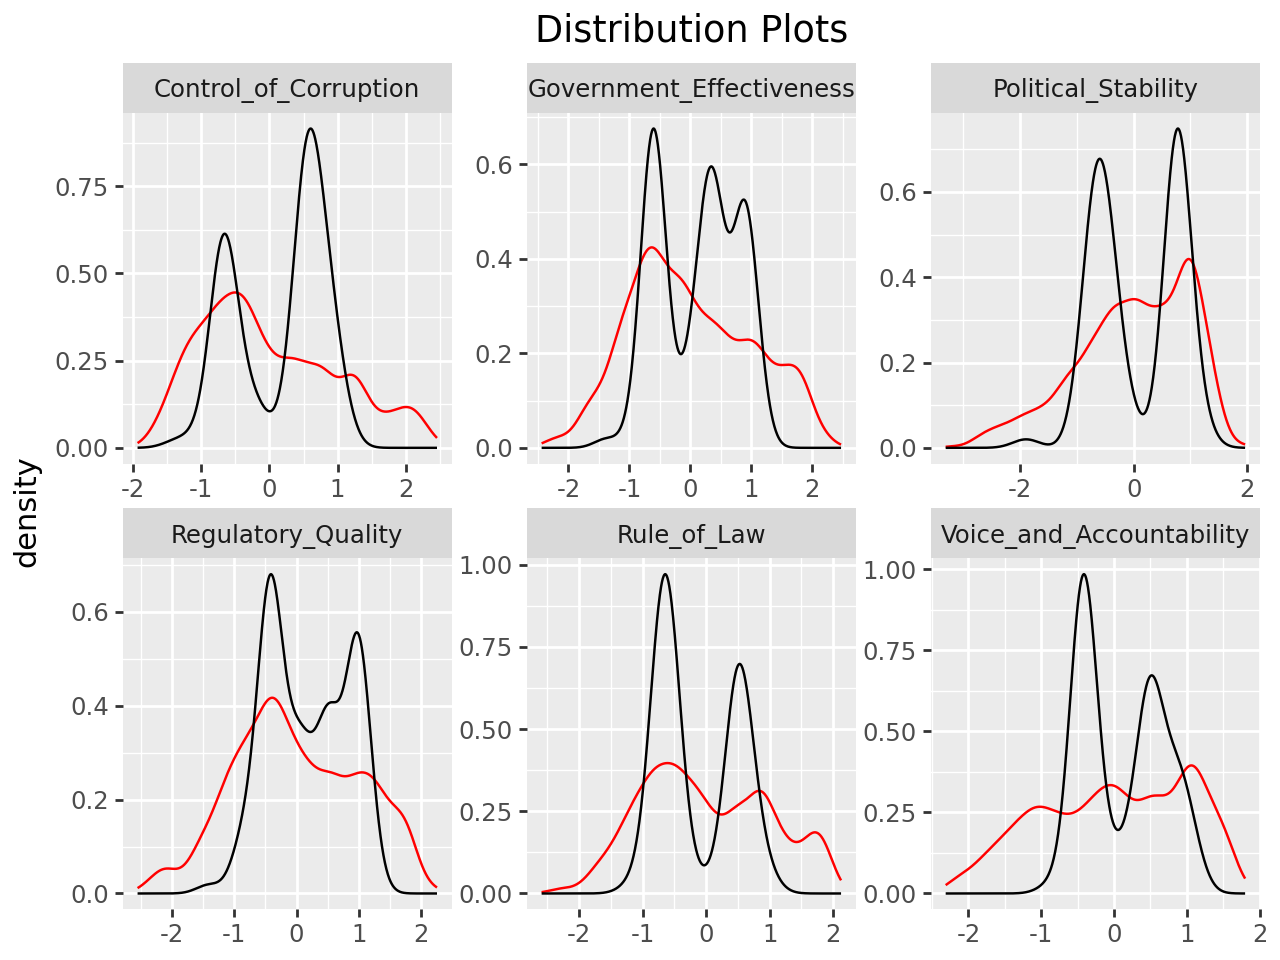

In [5]:
kernel.plot_imputed_distributions()

In [6]:
optimal_params = kernel.tune_parameters(
    dataset=0, 
    use_gbdt=True,
    num_iterations=500,
    random_state=1,
)
kernel.mice(1, variable_parameters=optimal_params)
pd.DataFrame(optimal_params)

,Government_Effectiveness,Regulatory_Quality,Control_of_Corruption,Political_Stability,Voice_and_Accountability,Rule_of_Law
boosting,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt
data_sample_strategy,bagging,bagging,bagging,bagging,bagging,bagging
num_iterations,500,500,500,500,500,500
max_depth,5,4,4,5,3,4
num_leaves,23,17,24,18,18,15
min_data_in_leaf,2,7,6,1,68,8
min_sum_hessian_in_leaf,0.01,0.01,0.01,0.01,0.01,0.01
min_gain_to_split,0.0,0.0,0.0,0.0,0.0,0.0
bagging_fraction,0.999136,0.501521,0.307914,0.779917,0.484219,0.989755
feature_fraction_bynode,0.31248,0.299912,0.580104,0.778489,0.776686,0.621771


In [7]:
kernel.mice(30,variable_parameters=optimal_params)
imputed_data = kernel.complete_data(0)

imputed_data['Country'] = data['Country']
imputed_data['Year'] = data['Year']

imputed_data.to_csv('Institutional_Index.csv', index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



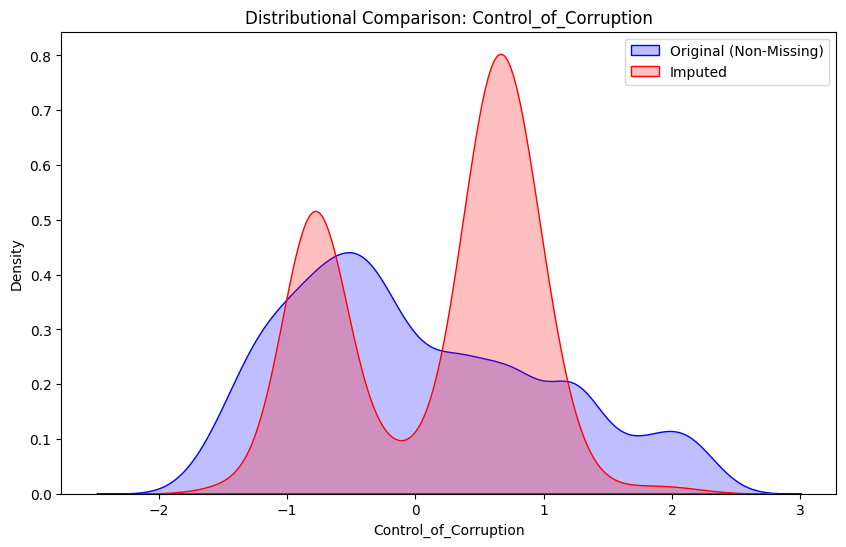

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



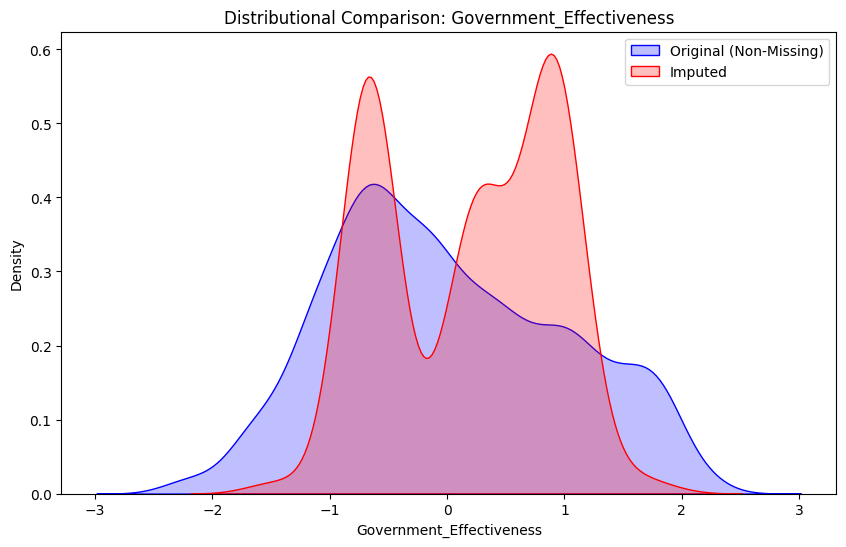

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



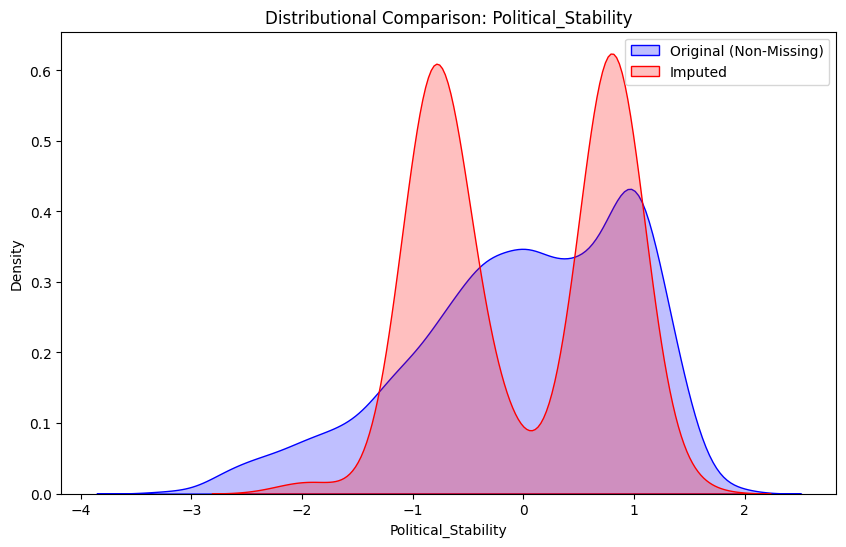

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



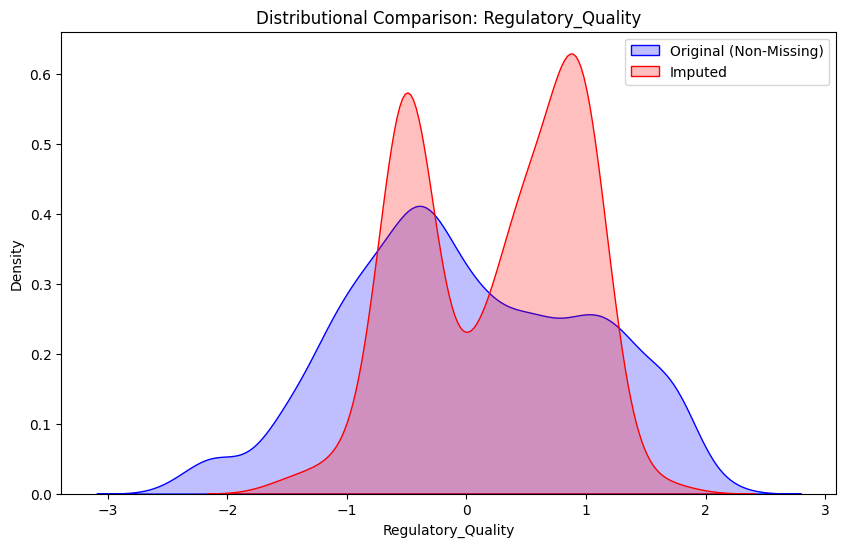

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



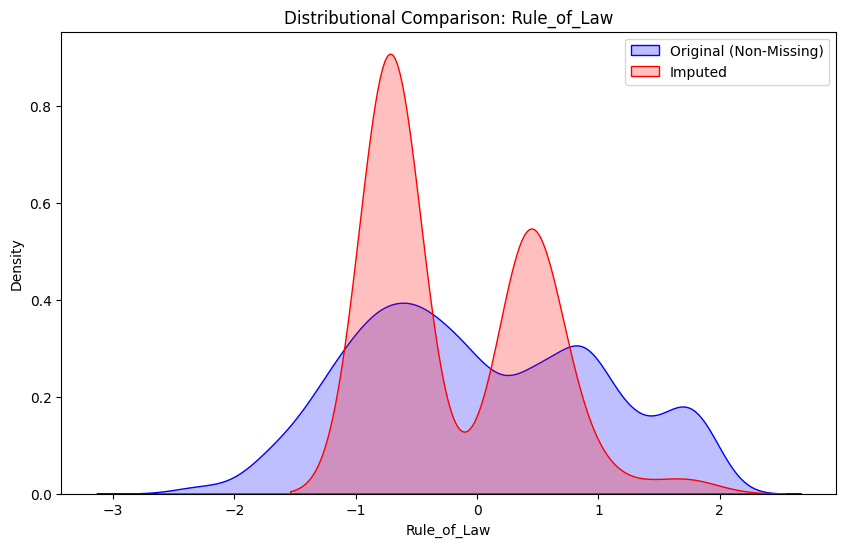

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\4172480332.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



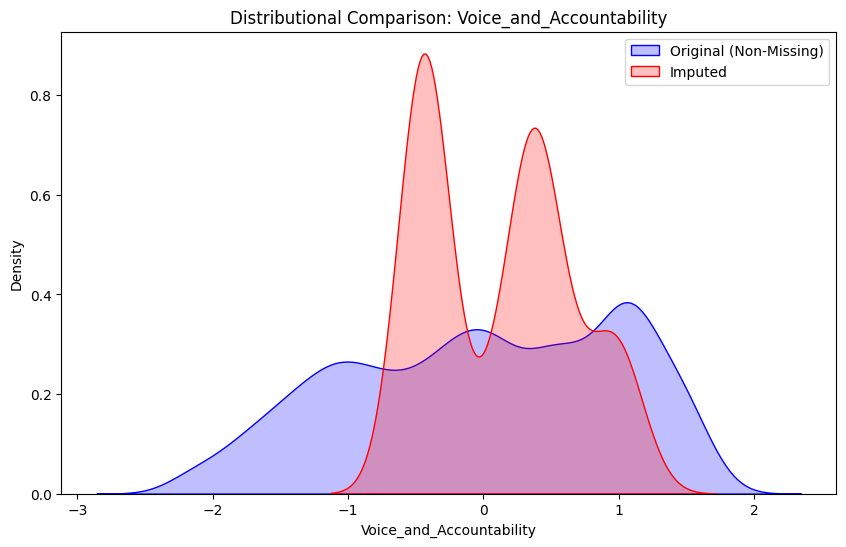

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

original_data = pd.read_csv("Institutional_data_full.csv")

original_data_clean = original_data.drop(['Country', 'Year'], axis=1)
imputed_data_clean = imputed_data.drop(['Country', 'Year'], axis=1)

original_data_clean = original_data_clean.apply(pd.to_numeric, errors='coerce')
imputed_data_clean = imputed_data_clean.apply(pd.to_numeric, errors='coerce')

def plot_distributions(original, imputed, column_name):
    plt.figure(figsize=(10, 6))

    sns.kdeplot(original.dropna(), label="Original (Non-Missing)", color='blue', shade=True)
    missing_indices = original[original.isna()].index
    sns.kdeplot(imputed.loc[missing_indices], label="Imputed", color='red', shade=True)
    
    plt.title(f'Distributional Comparison: {column_name}')
    plt.legend()
    plt.show()


for column in original_data_clean.columns:
    plot_distributions(original_data_clean[column], imputed_data_clean[column], column)

In [9]:
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from factor_analyzer.factor_analyzer import calculate_kmo

df = pd.read_csv("Institutional_Index.csv")

df= df.interpolate(method='linear', limit_direction='forward', axis=0)

df_numeric = df.drop(columns=['Country', 'Year'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

kmo_all,kmo_model=calculate_kmo(df_scaled)
kmo_model

C:\Users\Admin\AppData\Local\Temp\ipykernel_4856\2968669245.py:7: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.


0.9014420327387449